# Lead Conversion Prediction

## Business Context
EdTech platforms like ExtraaLearn generate large volumes of leads, but only a fraction 
convert to paying customers. Identifying high-probability leads early allows sales teams 
to allocate resources efficiently and improve conversion rates.

## Objective
Using behavioral and demographic data from ExtraaLearn, this project:
* Builds a classification model to predict lead conversion probability
* Identifies the key factors driving conversion
* Provides actionable recommendations for sales prioritization

## Data Description
4,612 leads with 14 features capturing demographics, platform behavior, and marketing 
touchpoints. Target variable: `status` (1 = converted, 0 = not converted).

| Feature | Description |
|---|---|
| `age` | Age of the lead |
| `current_occupation` | Professional, Student, or Unemployed |
| `first_interaction` | Website or Mobile App |
| `profile_completed` | Low / Medium / High completion |
| `website_visits` | Number of website visits |
| `time_spent_on_website` | Total seconds spent on site |
| `page_views_per_visit` | Average pages viewed per visit |
| `last_activity` | Email, Phone, or Website activity |
| `print_media_type1/2` | Newspaper / Magazine ad exposure |
| `digital_media` | Digital platform ad exposure |
| `educational_channels` | Heard via education forums |
| `referral` | Heard via referral |

## Libraries

In [1]:
# Standard library
import os
import sys
import warnings

sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

# Data
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Modeling
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# Serialization
import joblib

# Local
from src.data_loader import load_data
from src.data_preprocessing import preprocess_data
from src.eda import (
    categorical_overview,
    head_and_tail,
    histogram_boxplot,
    labeled_barplot,
    stacked_barplot,
    distribution_plot_wrt_target,
)
from src.evaluate import model_performance_classification
from src.model import train_decision_tree

# **Loading the dataset**

In [2]:
original_dataset = load_data('../data/ExtraaLearn.csv')


In [3]:
data = original_dataset.copy()

## Overview of the dataset

In [4]:
head_and_tail(data)

Head:


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0



Tail:


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


In [5]:
data.shape

(4612, 15)

* The dataset has 4612 rows and 15 columns

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   str    
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   str    
 3   first_interaction      4612 non-null   str    
 4   profile_completed      4612 non-null   str    
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   str    
 9   print_media_type1      4612 non-null   str    
 10  print_media_type2      4612 non-null   str    
 11  digital_media          4612 non-null   str    
 12  educational_channels   4612 non-null   str    
 13  referral               4612 non-null   str    
 14  status                 4612 non-null   int64  
dtypes: float64(1), 

* No null values across all 4,612 records. 10 categorical features, 4 numerical, 1 float. Target variable: `status` (int).

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data["ID"].nunique()

4612

* Dataset has no duplicate values. All ID values are unique.

In [9]:
data.columns.tolist()

['ID',
 'age',
 'current_occupation',
 'first_interaction',
 'profile_completed',
 'website_visits',
 'time_spent_on_website',
 'page_views_per_visit',
 'last_activity',
 'print_media_type1',
 'print_media_type2',
 'digital_media',
 'educational_channels',
 'referral',
 'status']

## Preprocessing

The ID column is dropped as it carries no predictive value.

In [10]:
data = preprocess_data(data)
data

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4607,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0


In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [12]:
data.isnull().sum()

age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64

* There are no null values in the dataset.

# **Exploratory Data Analysis**

In [13]:
cat_cols = list(data.select_dtypes("object").columns)

for column in cat_cols:
    print(data[column].value_counts())
    print("-" * 50)

current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
print_media_type2
No     4379
Yes     233
Name: count, dtype: int64
--------------------------------------------------
digital_media
No     4085
Yes     527
Name: count, dtype: int64
--------------------------------------------------
educational_channels
No     3907
Yes     705
Name

### Overview of categorical variables
Here we'll have a glance at the percentage count for each categorical variable.          n = 4612

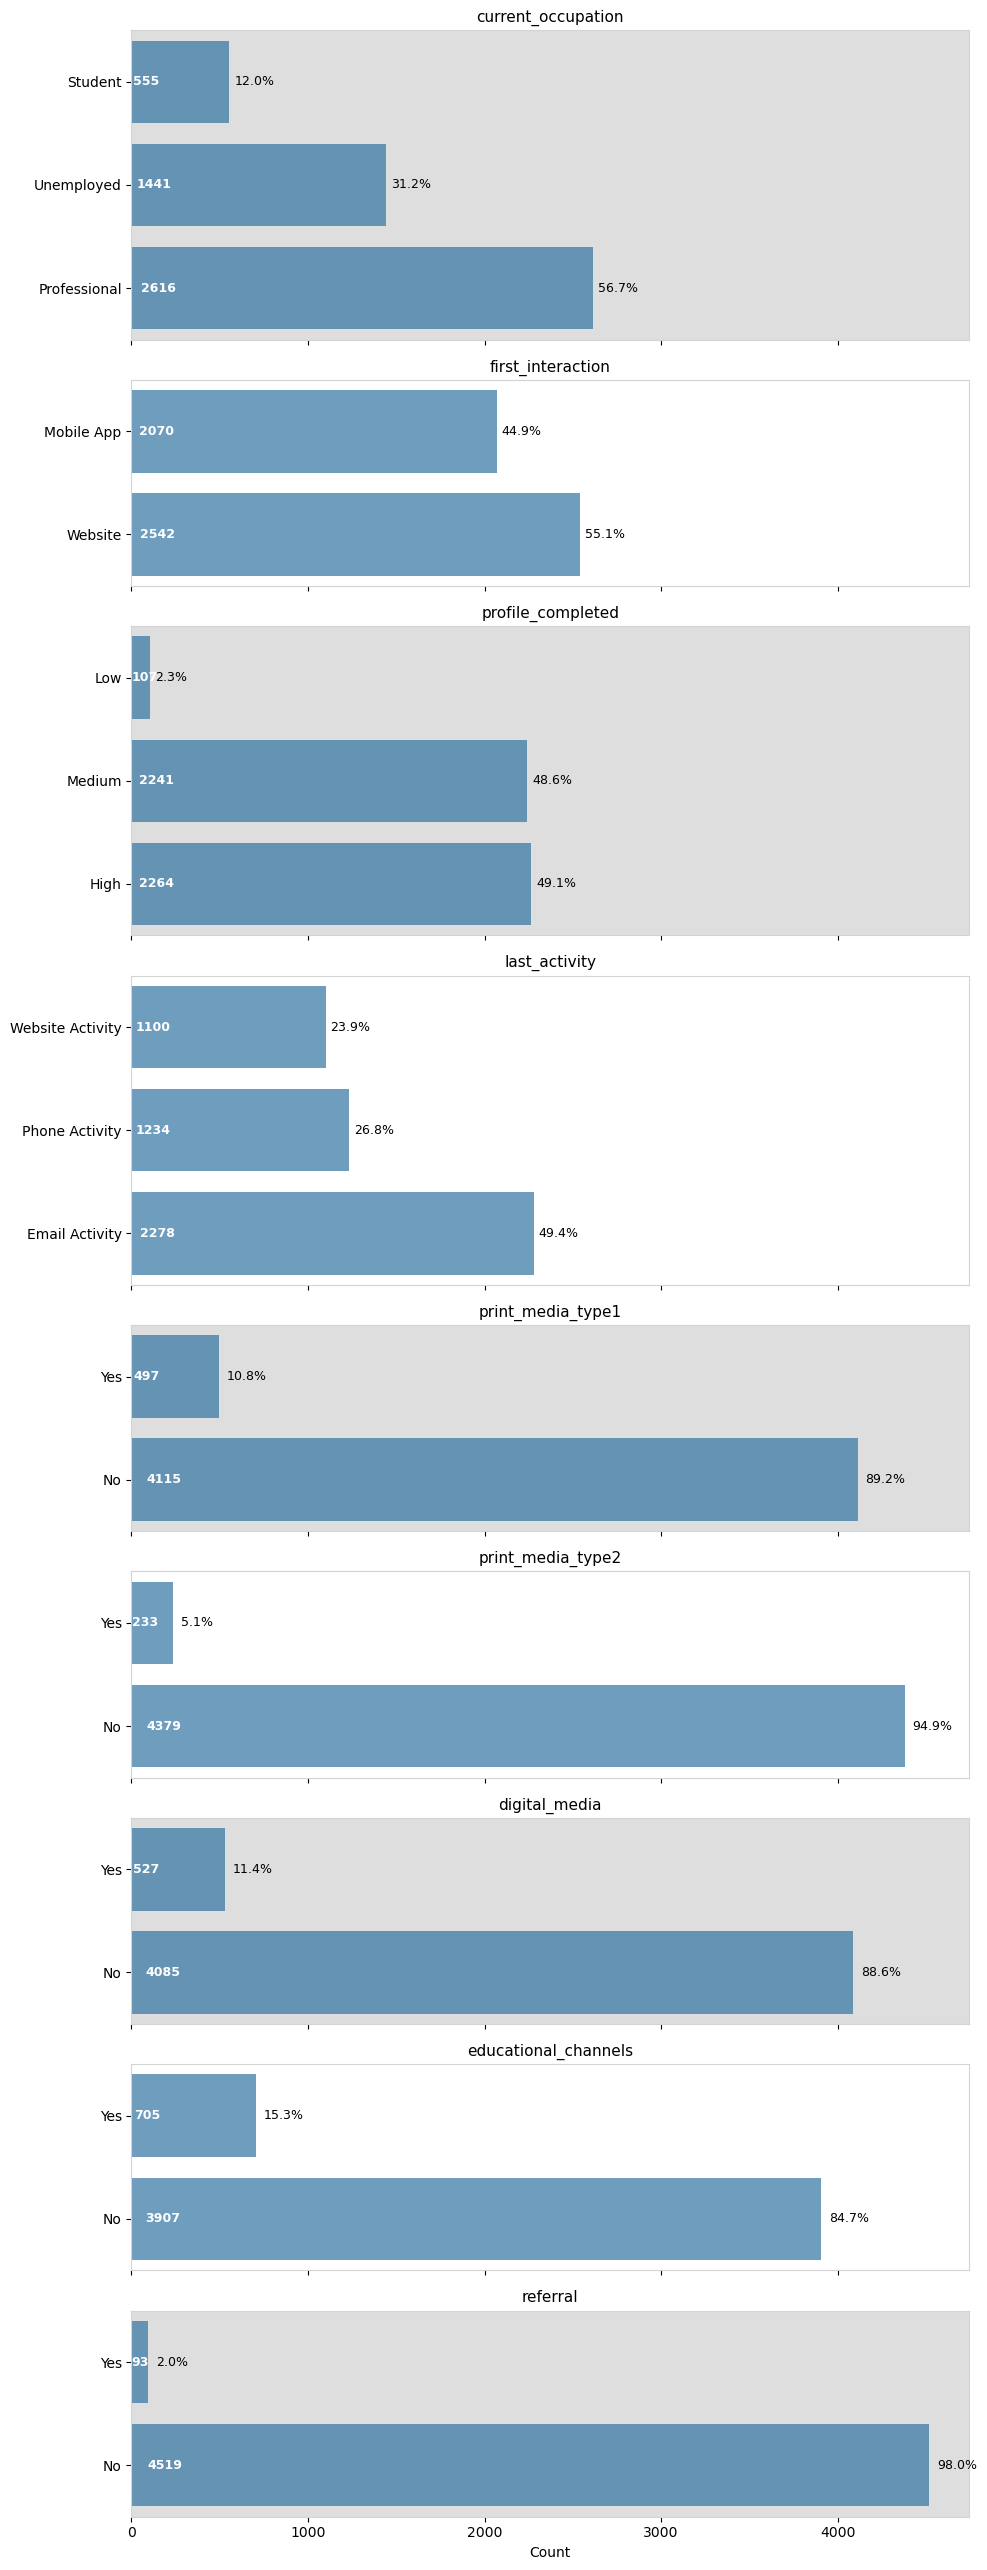

In [14]:
categorical_overview(data, cat_cols)

* Shared count axis allows direct comparison of class distribution across all categorical features, revealing imbalance at a glance.

### Overview of numerical variables

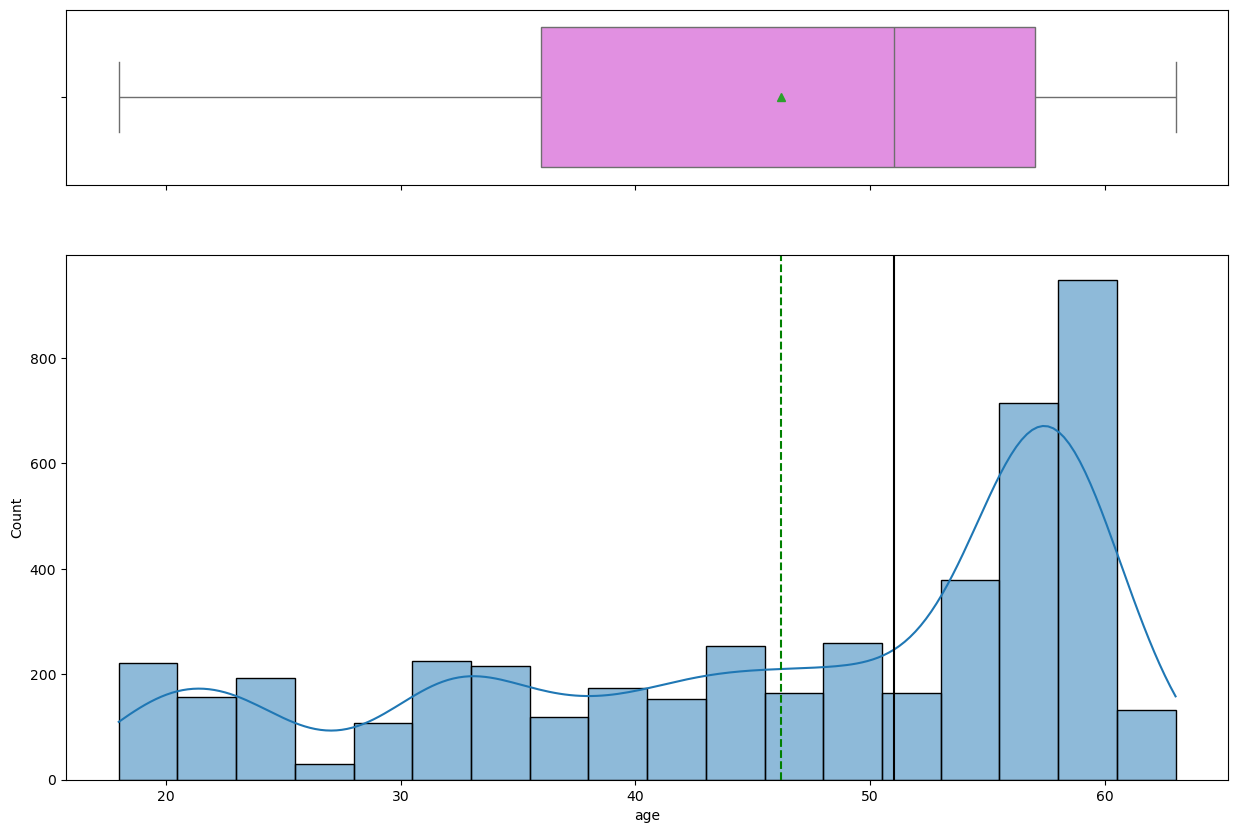

In [15]:
histogram_boxplot(data, "age", kde=True)

* Age is left skewed, with the mean around 46 and the median around 51.

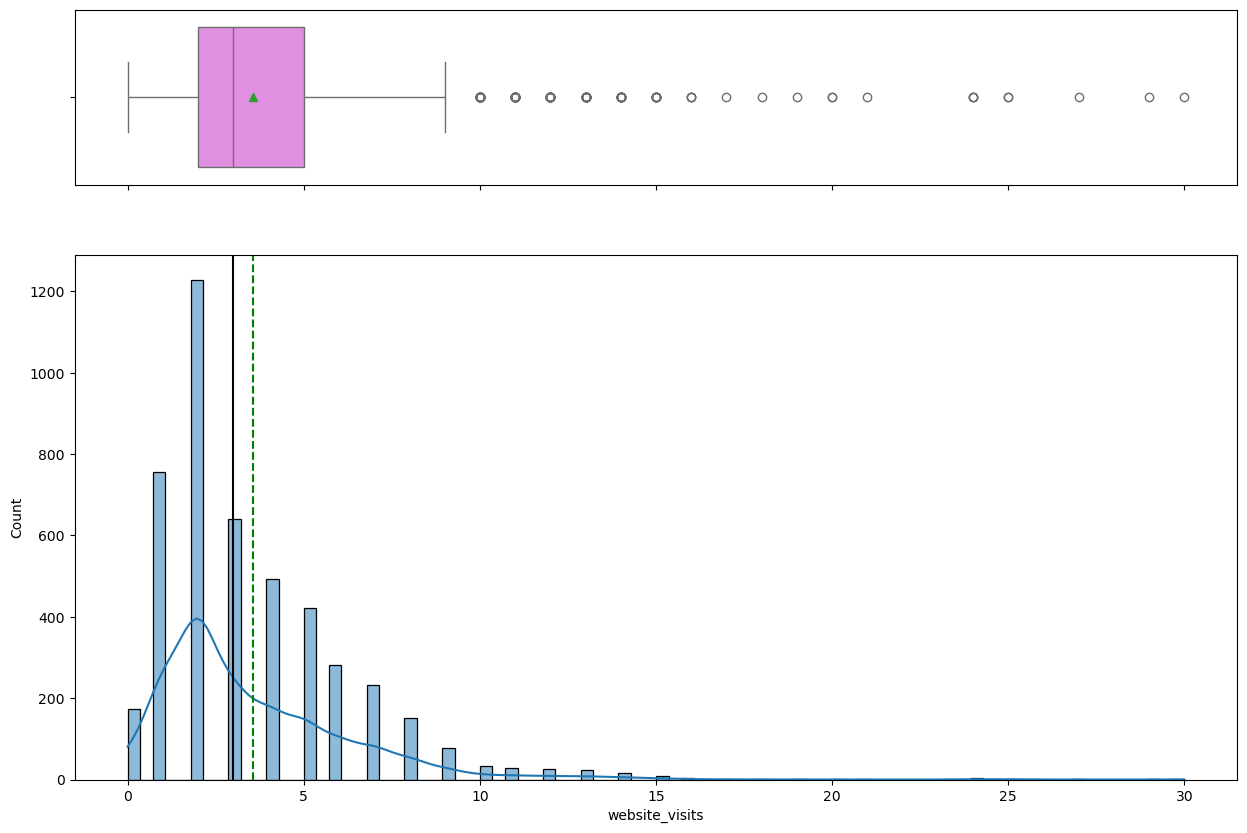

In [16]:
histogram_boxplot(data, "website_visits", kde=True)

* 75% of the leads have visited the website less than 5 times.

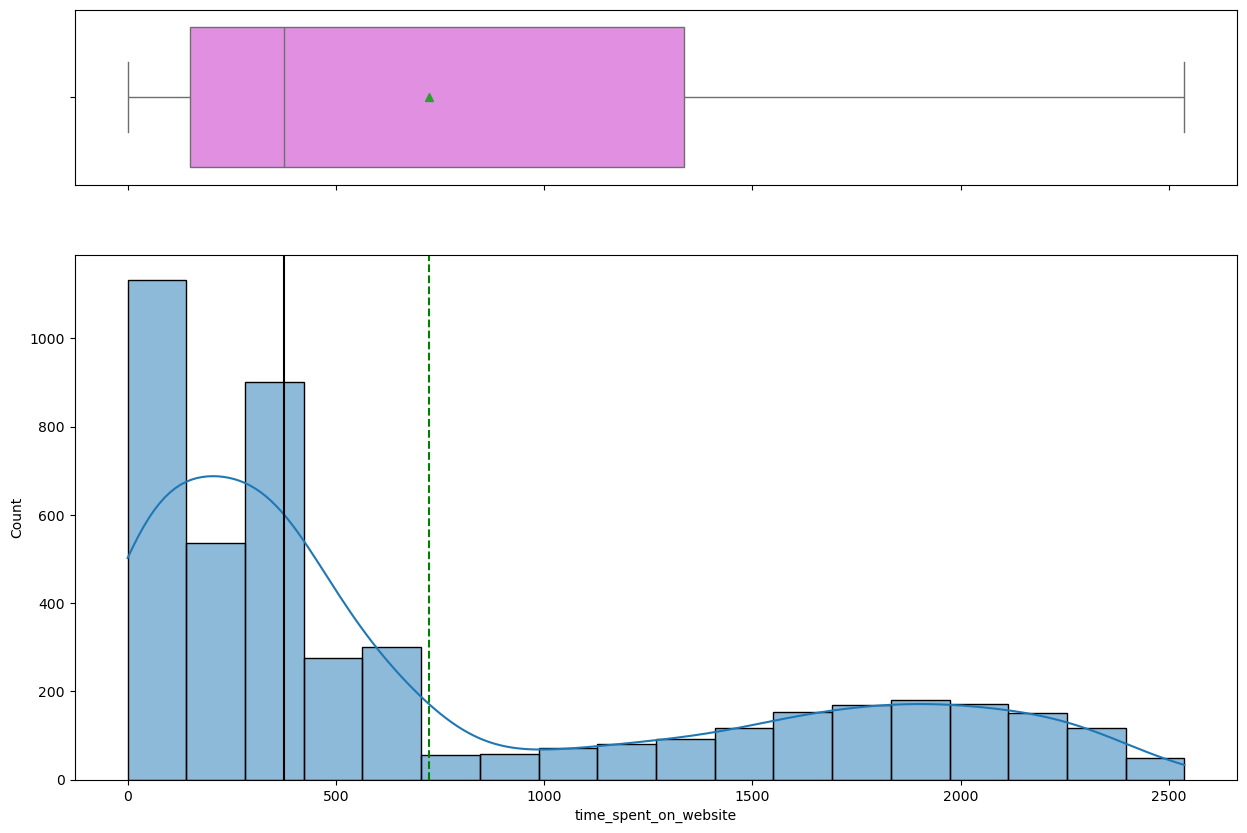

In [17]:
histogram_boxplot(data, "time_spent_on_website", kde=True)

* Time spent on website is right skewed — most leads spent fewer than 1,500 seconds on the site.

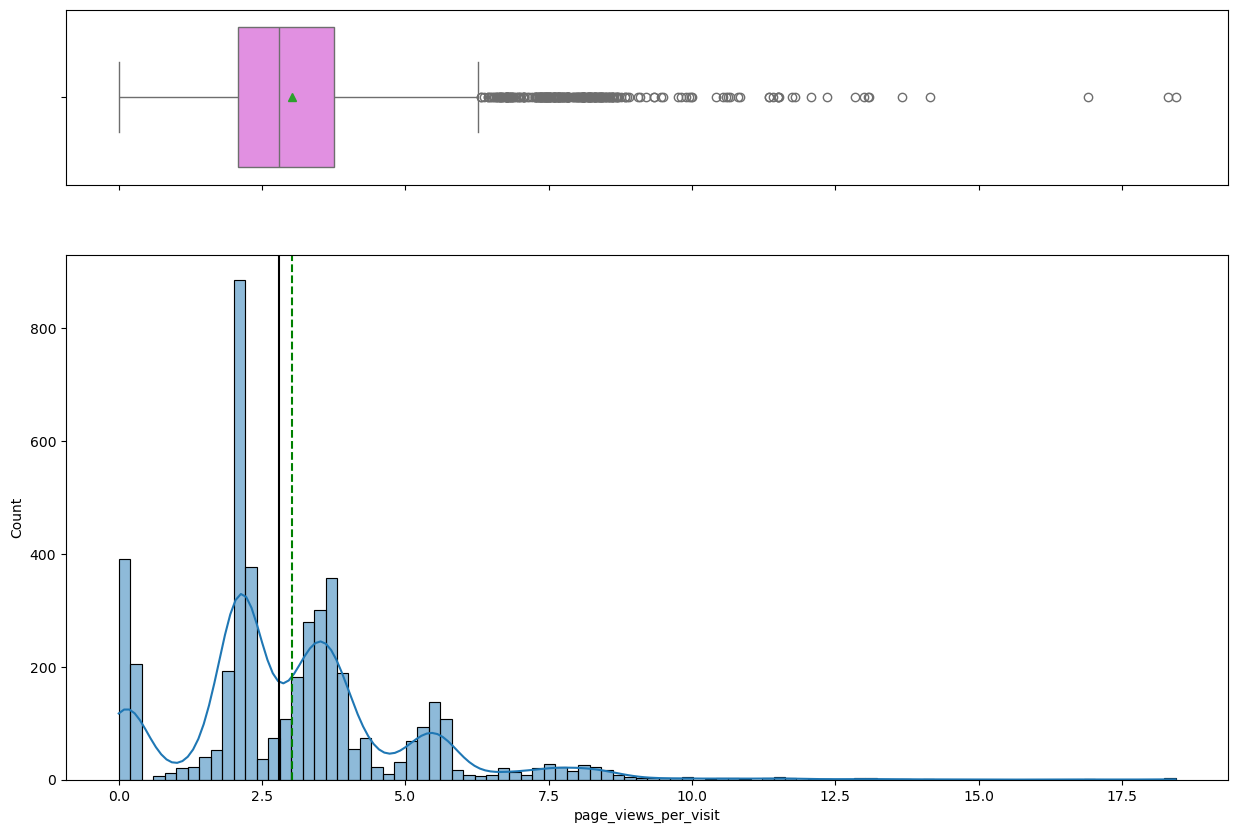

In [18]:
histogram_boxplot(data, "page_views_per_visit", kde=True)

* Page views per visit is right skewed. The high concentration of leads with near-zero or zero page views pulls the mean and median closer together than typical right skewed distributions.

### Bivariate Analysis

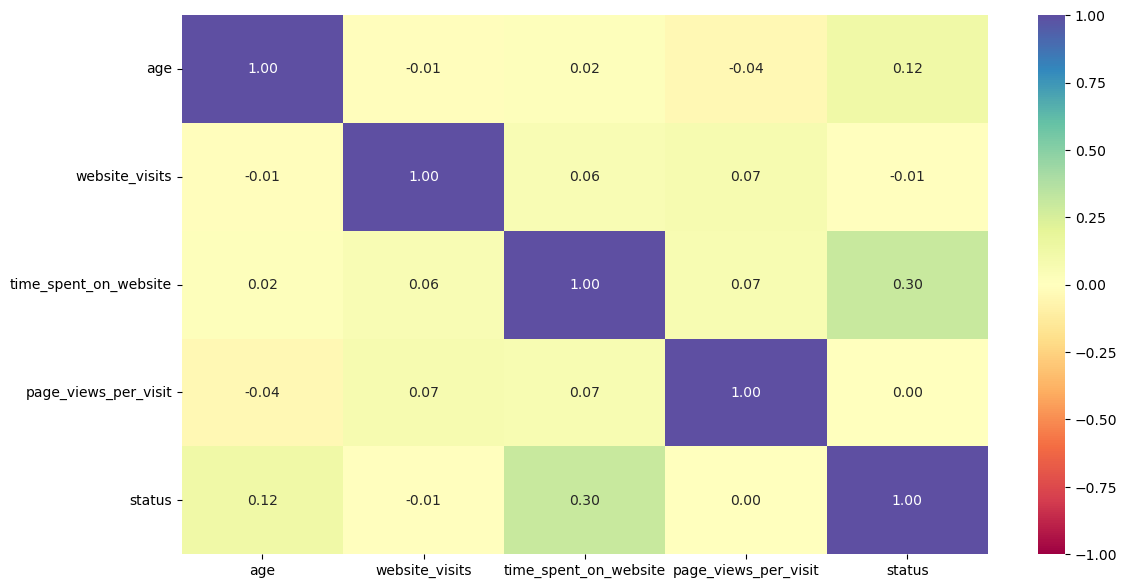

In [19]:
plt.figure(figsize=(13, 7))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* Time spent on website is the strongest predictor of conversion (status) among numerical features. Age shows slight positive correlation. Remaining numerical variables show negligible correlation with the target.

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


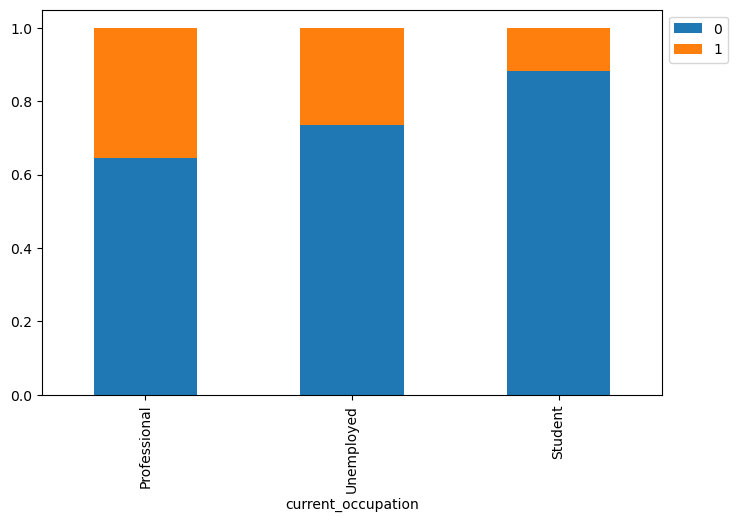

In [20]:
stacked_barplot(data, "current_occupation", "status")

* Professionals represent the largest and highest-converting segment among all occupations.

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


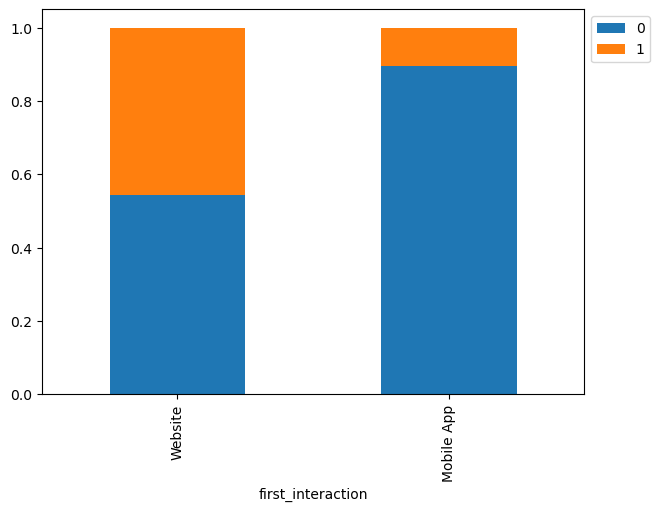

In [21]:
stacked_barplot(data, "first_interaction", "status")

* Website is the dominant first interaction channel, and leads who first interact via website convert at a higher rate.

status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


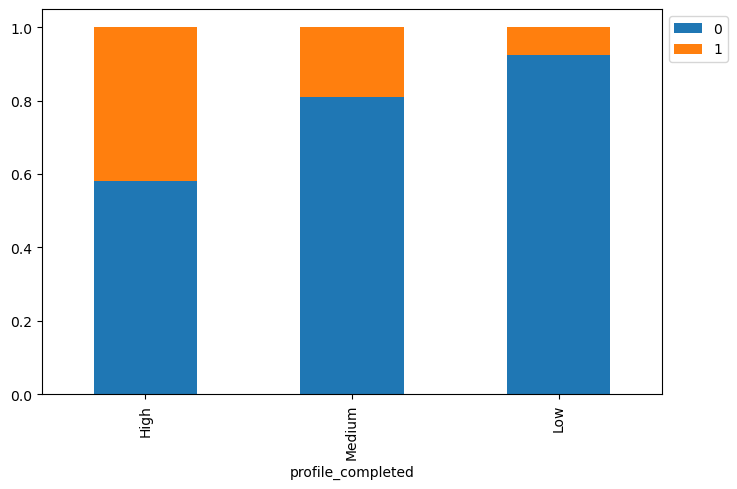

In [22]:
stacked_barplot(data, "profile_completed", "status")

* Profile completion is strongly associated with conversion — high completion leads convert most frequently and in the greatest numbers.

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


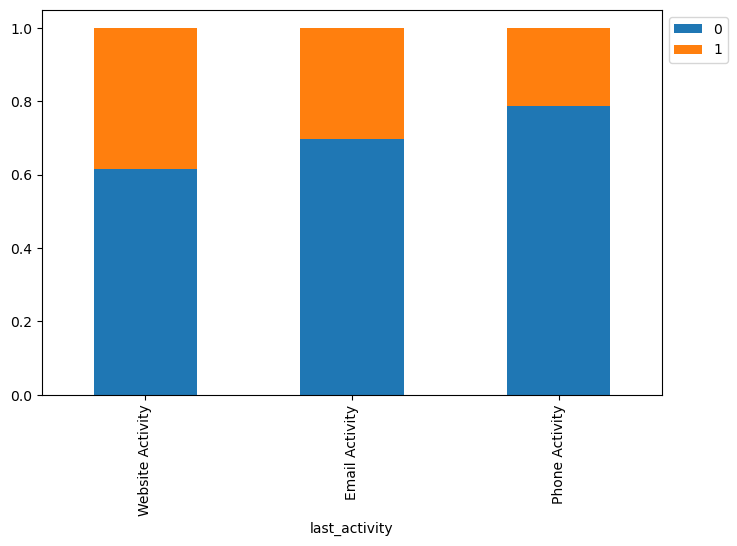

In [23]:
stacked_barplot(data, "last_activity", "status")

* Leads whose last activity was website interaction show the highest conversion proportion.

# **Data Preprocessing**

## Outlier Check

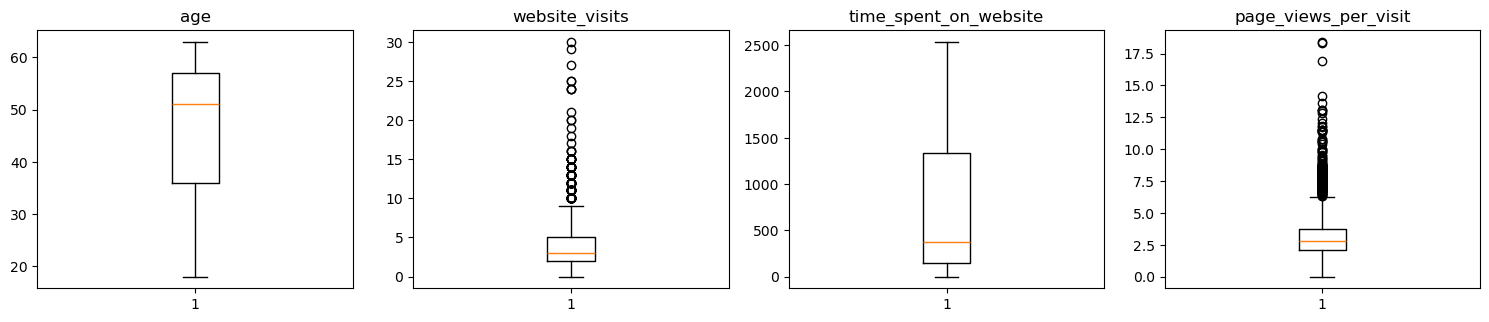

In [24]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

* Outliers are present in website_visits and page_views_per_visit. Decision trees are robust to outliers by nature, so no treatment is applied.

## Data Preparation for modeling

The target variable is `status`. Categorical features require encoding before modeling. 
Data is split 70/30 into train and test sets. Class distribution is consistent across 
both splits (≈70/30), confirming the random split is representative.

In [25]:
X = data.drop(["status"], axis=1)
Y = data["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [26]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3228, 13)
Shape of test set :  (1384, 13)
Percentage of classes in training set:
status
0    0.704151
1    0.295849
Name: proportion, dtype: float64
Percentage of classes in test set:
status
0    0.695087
1    0.304913
Name: proportion, dtype: float64


The dataset presents a class imbalance (≈70% non-converted, 30% converted). 
Recall is prioritized as the key evaluation metric to minimize missed conversion opportunities.

## **Data Pre-processing Pipeline**

In [27]:
categorical_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features

['current_occupation',
 'first_interaction',
 'profile_completed',
 'last_activity',
 'print_media_type1',
 'print_media_type2',
 'digital_media',
 'educational_channels',
 'referral']

In [28]:
preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
)

# **Model Building**

## Evaluation Criterion

* Recall and F1 score are particularly important for this problem, since we are looking to capture as many converters as possible.

## Decision Tree Model

In [29]:
dtree = train_decision_tree(preprocessor, X_train, y_train)
dtree

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

### Checking model performance on training set

In [30]:
dtree_train_perf = model_performance_classification(dtree, X_train, y_train)
dtree_train_perf

,Accuracy,Recall,Precision,F1
0,0.830235,0.634555,0.752795,0.688636


* Training set performance is strong across all metrics. Recall of 63.5% and F1 of 68.9% 
suggest the model is learning meaningful patterns from the data.

### Checking model performance on test set

In [31]:
dtree_test_perf = model_performance_classification(dtree, X_test, y_test)
dtree_test_perf

,Accuracy,Recall,Precision,F1
0,0.784682,0.580569,0.669399,0.621827


* Performance drops on the test set — Recall falls to 58.1% and F1 to 62.2% — indicating 
moderate overfitting. The model generalizes reasonably but has learned some noise from the 
training data. Hyperparameter tuning is applied next to address this.

## Hyperparameter Tuning

GridSearchCV is applied to optimize `max_depth`, `max_leaf_nodes`, and `min_samples_leaf`, 
using Recall as the scoring metric across 5-fold cross-validation.

In [32]:
dtree_tuned = DecisionTreeClassifier(random_state=1)
dtree_tuned = make_pipeline(preprocessor,dtree_tuned)

parameters = {
    "decisiontreeclassifier__max_depth": [None, 5, 10, 15, 20],
    "decisiontreeclassifier__max_leaf_nodes": [20, 30, 40, 50, 60],
    "decisiontreeclassifier__min_samples_leaf": [1, 2, 3, 5]
}

grid_obj = GridSearchCV(dtree_tuned, parameters, scoring="recall", cv=5, n_jobs =-1)
grid_obj = grid_obj.fit(X_train, y_train)
print(grid_obj.best_params_)

dtree_tuned = grid_obj.best_estimator_
dtree_tuned.fit(X_train, y_train);

{'decisiontreeclassifier__max_depth': None, 'decisiontreeclassifier__max_leaf_nodes': 60, 'decisiontreeclassifier__min_samples_leaf': 1}


### Checking model performance on training set

In [33]:
dtree_tuned_train_perf = model_performance_classification(dtree_tuned, X_train, y_train)
dtree_tuned_train_perf

,Accuracy,Recall,Precision,F1
0,0.825589,0.636649,0.737864,0.68353


### Checking model performance on test set

In [34]:
dtree_tuned_test_perf = model_performance_classification(dtree_tuned, X_test, y_test)
dtree_tuned_test_perf

,Accuracy,Recall,Precision,F1
0,0.787572,0.582938,0.675824,0.625954


* Tuning yields marginal improvement — Recall increases from 58.1% to 58.3% and F1 from 
62.2% to 62.6%. The baseline model was already near the decision tree's performance ceiling 
on this dataset. Ensemble methods are the logical next step.

## **Model Performance Comparison**

In [35]:
models_train_comp_df = pd.concat(
    [
        dtree_train_perf.T,
        dtree_tuned_train_perf.T
    ],
    axis=1,
)

models_train_comp_df.columns = ["Decision Tree", "Decision Tree Tuned"]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Decision Tree Tuned
Accuracy,0.830235,0.825589
Recall,0.634555,0.636649
Precision,0.752795,0.737864
F1,0.688636,0.683530


In [36]:
models_test_comp_df = pd.concat(
    [
        dtree_test_perf.T,
        dtree_tuned_test_perf.T
    ],
    axis=1,
)

models_test_comp_df.columns = ["Decision Tree","Decision Tree Tuned"]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Decision Tree Tuned
Accuracy,0.784682,0.787572
Recall,0.580569,0.582938
Precision,0.669399,0.675824
F1,0.621827,0.625954


* Tuning yields marginal improvement on the test set, confirming the baseline model was already near 
the decision tree's performance ceiling. The slight train/test gap in the baseline 
indicates minor overfitting, largely corrected by tuning.


* **The tuned decision tree is chosen as the most generalizable model to serialize.**

### Feature Importance

In [37]:
ohe = dtree_tuned.named_steps["columntransformer"] \
        .named_transformers_["pipeline"] \
        .named_steps["encoder"]

feature_names = ohe.get_feature_names_out(categorical_features)

importances = dtree_tuned.named_steps["decisiontreeclassifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
3,first_interaction_Mobile App,0.364609
5,profile_completed_High,0.303776
1,current_occupation_Student,0.095498
9,last_activity_Phone Activity,0.049030
2,current_occupation_Unemployed,0.039924
0,current_occupation_Professional,0.031369
8,last_activity_Email Activity,0.024914
18,educational_channels_Yes,0.015260
19,referral_No,0.011650
10,last_activity_Website Activity,0.010249


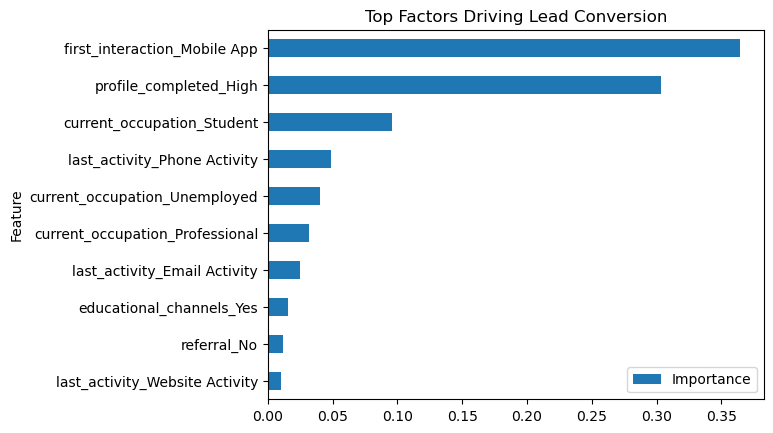

In [38]:
feature_importance_df.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance"
)

plt.gca().invert_yaxis()
plt.title("Top Factors Driving Lead Conversion")
plt.show()

* First interaction via mobile app and high profile completion are the strongest drivers 
of lead conversion. This aligns with the earlier observation that time spent on the 
website correlates significantly with conversion.

## Model Serialization

In [39]:
os.makedirs("../backend_files", exist_ok=True)
saved_model_path = "../backend_files/learn_model.joblib"
joblib.dump(dtree_tuned, saved_model_path)

['../backend_files/learn_model.joblib']

In [40]:
saved_model = joblib.load(saved_model_path)
assert (saved_model.predict(X_test) == dtree_tuned.predict(X_test)).all(), "Model mismatch!"
print("Model verified successfully.")

Model verified successfully.


## Deployment

The serialized model is saved to `backend_files/learn_model.joblib` and loaded by the Streamlit app in `app/`. See `app/` for deployment details.

## Actionable Insights and Recommendations

* Profile completion and first interaction channel are the strongest behavioral signals 
for conversion. Sales teams should prioritize leads with high profile completion and 
website-first interactions.
* Variables showing weaker correlation with conversion represent untapped opportunity — 
targeted campaigns through print and digital media could improve engagement among 
currently low-converting segments.
* The model can be integrated into a lead scoring workflow, updated periodically as new 
conversion data becomes available.